Using device: cuda
IC pretraining...
IC    0 | loss 9.630e-02
IC  300 | loss 4.018e-03
IC  600 | loss 3.568e-03
IC  900 | loss 3.473e-03
IC 1200 | loss 3.389e-03
Adam training...
   0 | total 2.895e+00 | mass 2.735e+00
 500 | total 6.954e-02 | mass 1.835e-03
1000 | total 6.423e-02 | mass 2.231e-04
1500 | total 6.235e-02 | mass 5.851e-05
2000 | total 6.069e-02 | mass 4.851e-05
2500 | total 5.921e-02 | mass 9.845e-05
3000 | total 5.784e-02 | mass 1.217e-04
3500 | total 5.658e-02 | mass 9.420e-05
L-BFGS fine tuning...
L-BFGS done.


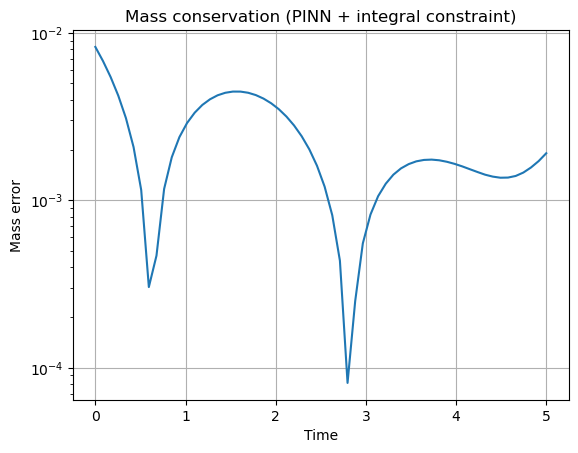

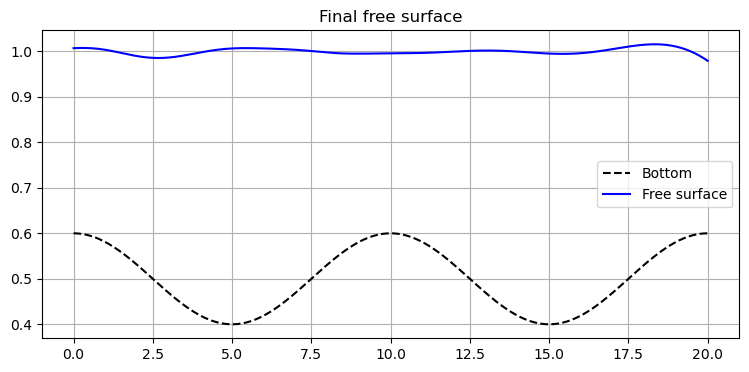

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# PHYSICAL PARAMETERS
# ============================================================
g = 9.81
L = 20.0
T_end = 5.0

b0, Ab, Lb = 0.5, 0.1, 10.0

def bottom_profile(x):
    return b0 + Ab * torch.cos(2*np.pi*x/Lb)

def bottom_gradient(x):
    return -Ab * torch.sin(2*np.pi*x/Lb) * (2*np.pi/Lb)

# ============================================================
# PINN MODEL (CONSERVATIVE)
# ============================================================
class PINN_SWE(nn.Module):
    def __init__(self, layers=[2, 16, 16, 2]):
        super().__init__()
        self.layers = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)]
        )

    def forward(self, xt):
        z = xt
        for layer in self.layers[:-1]:
            z = torch.tanh(layer(z))
        out = self.layers[-1](z)

        h_raw = out[:, 0:1]
        u = out[:, 1:2]

        # Smooth positivity
        h = torch.nn.functional.softplus(h_raw) + 1e-6
        return h, u

    def residuals(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        xt = torch.cat([x, t], dim=1)
        h, u = self(xt)
        hu = h * u

        h_t = torch.autograd.grad(h, t, torch.ones_like(h), create_graph=True)[0]
        hu_t = torch.autograd.grad(hu, t, torch.ones_like(hu), create_graph=True)[0]
        hu_x = torch.autograd.grad(hu, x, torch.ones_like(hu), create_graph=True)[0]

        flux = h*u**2 + 0.5*g*h**2
        flux_x = torch.autograd.grad(flux, x, torch.ones_like(flux), create_graph=True)[0]

        b_x = bottom_gradient(x)

        r_h  = h_t + hu_x
        r_hu = hu_t + flux_x + g*h*b_x
        return r_h, r_hu

# ============================================================
# INITIAL CONDITIONS
# ============================================================
def initial_conditions(x):
    H0, Ap, xc, sigma = 1.0, 0.00, L/2, 0.6
    b = bottom_profile(x)
    pulse = Ap * torch.exp(-(x-xc)**2/(2*sigma**2))
    h0 = H0 - b + pulse
    u0 = torch.zeros_like(x)
    return h0, u0

# ============================================================
# TRAINING DATA
# ============================================================
Nf, Nic, Nbc = 15000, 800, 400

x_f = (L * torch.rand(Nf,1)).to(device)
t_f = (T_end * torch.rand(Nf,1)).to(device)

x_ic = (L * torch.rand(Nic,1)).to(device)
t_ic = torch.zeros_like(x_ic)

t_bc = (T_end * torch.rand(Nbc,1)).to(device)
x_bc_L = torch.zeros_like(t_bc)
x_bc_R = L * torch.ones_like(t_bc)

# ============================================================
# MODEL & OPTIMIZER
# ============================================================
model = PINN_SWE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# IC PRETRAINING
# ============================================================
print("IC pretraining...")
for ep in range(1500):
    opt.zero_grad()
    h0,u0 = initial_conditions(x_ic)
    hp,up = model(torch.cat([x_ic,t_ic],1))
    loss = torch.mean((hp-h0)**2) + torch.mean(up**2)
    loss.backward()
    opt.step()
    if ep % 300 == 0:
        print(f"IC {ep:4d} | loss {loss.item():.3e}")

# ============================================================
# GLOBAL MASS REFERENCE
# ============================================================
Nx_mass = 400
xg = torch.linspace(0,L,Nx_mass).view(-1,1).to(device)
with torch.no_grad():
    h0,_ = initial_conditions(xg)
    M0 = torch.trapz(h0.squeeze(), xg.squeeze())

tg_mass = torch.linspace(0,T_end,15).to(device)

def mass_loss(model):
    loss = 0.0
    for t in tg_mass:
        h,_ = model(torch.cat([xg, t*torch.ones_like(xg)],1))
        Mt = torch.trapz(h.squeeze(), xg.squeeze())
        loss += (Mt - M0)**2
    return loss / len(tg_mass)

# ============================================================
# ADAM TRAINING (FULL PHYSICS)
# ============================================================
print("Adam training...")
for ep in range(4000):
    opt.zero_grad()

    r_h, r_hu = model.residuals(x_f, t_f)
    loss_pde = torch.mean(r_h**2) + torch.mean(r_hu**2)

    h0,u0 = initial_conditions(x_ic)
    hp,up = model(torch.cat([x_ic,t_ic],1))
    loss_ic = torch.mean((hp-h0)**2) + torch.mean(up**2)

    _,uL = model(torch.cat([x_bc_L,t_bc],1))
    _,uR = model(torch.cat([x_bc_R,t_bc],1))
    loss_bc = torch.mean(uL**2) + torch.mean(uR**2)

    loss_m = mass_loss(model)

    loss = loss_pde + 10*loss_ic + 10*loss_bc + loss_m
    loss.backward()
    opt.step()

    if ep % 500 == 0:
        print(f"{ep:4d} | total {loss.item():.3e} | mass {loss_m.item():.3e}")

# ============================================================
# L-BFGS FINE TUNING
# ============================================================
print("L-BFGS fine tuning...")
lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=1000,
    history_size=50,
    line_search_fn="strong_wolfe"
)

def closure():
    lbfgs.zero_grad()

    r_h, r_hu = model.residuals(x_f, t_f)
    loss_pde = torch.mean(r_h**2) + torch.mean(r_hu**2)

    h0,u0 = initial_conditions(x_ic)
    hp,up = model(torch.cat([x_ic,t_ic],1))
    loss_ic = torch.mean((hp-h0)**2) + torch.mean(up**2)

    _,uL = model(torch.cat([x_bc_L,t_bc],1))
    _,uR = model(torch.cat([x_bc_R,t_bc],1))
    loss_bc = torch.mean(uL**2) + torch.mean(uR**2)

    loss_m = mass_loss(model)

    loss = loss_pde + 5*loss_ic + 5*loss_bc + loss_m
    loss.backward()
    return loss

lbfgs.step(closure)
print("L-BFGS done.")

# ============================================================
# DIAGNOSTICS
# ============================================================
Nt = 60
tg = torch.linspace(0,T_end,Nt).to(device)
mass, momentum = [], []

with torch.no_grad():
    for t in tg:
        h,u = model(torch.cat([xg,t*torch.ones_like(xg)],1))
        mass.append(torch.trapz(h.squeeze(),xg.squeeze()).item())
        momentum.append(torch.trapz((h*u).squeeze(),xg.squeeze()).item())

mass = np.array(mass)
momentum = np.array(momentum)
mass_err = np.abs(mass - M0.item())

# ============================================================
# PLOTS
# ============================================================
plt.figure()
plt.semilogy(tg.cpu(), mass_err)
plt.xlabel("Time"); plt.ylabel("Mass error")
plt.title("Mass conservation (PINN + integral constraint)")
plt.grid(); plt.show()


with torch.no_grad():
    hF,_ = model(torch.cat([xg,T_end*torch.ones_like(xg)],1))
    HF = hF + bottom_profile(xg)

plt.figure(figsize=(9,4))
plt.plot(xg.cpu(), bottom_profile(xg).cpu(), 'k--', label="Bottom")
plt.plot(xg.cpu(), HF.cpu(), 'b', label="Free surface")
plt.legend(); plt.grid()
plt.title("Final free surface")
plt.show()


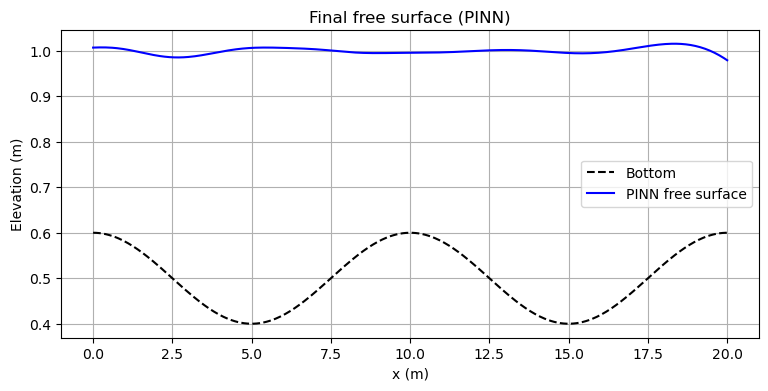

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Sampling grid (match PyClaw)
# ------------------------------------------------------------
Nx = 400
x = np.linspace(0.0, L, Nx).reshape(-1, 1)
t_final = T_end * np.ones_like(x)

x_t = torch.tensor(x, dtype=torch.float32).to(device)
t_t = torch.tensor(t_final, dtype=torch.float32).to(device)

# ------------------------------------------------------------
# PINN prediction
# ------------------------------------------------------------
model.eval()
with torch.no_grad():
    h_pred, u_pred = model(torch.cat([x_t, t_t], dim=1))

h_pred = h_pred.cpu().numpy().flatten()
u_pred = u_pred.cpu().numpy().flatten()

# Bottom & free surface
b = bottom_profile(torch.tensor(x, dtype=torch.float32)).numpy().flatten()
eta = h_pred + b

# ------------------------------------------------------------
# Plot: Final free surface (PINN)
# ------------------------------------------------------------
plt.figure(figsize=(9,4))
plt.plot(x, b, 'k--', label='Bottom')
plt.plot(x, eta, 'b', label='PINN free surface')
plt.xlabel('x (m)')
plt.ylabel('Elevation (m)')
plt.title('Final free surface (PINN)')
plt.legend()
plt.grid()
plt.show()


In [3]:
np.sqrt(((eta-1)**2).mean().item())

np.float64(0.0069405481497099054)